In [ ]:

%load_ext autoreload
%autoreload 2
from mGST.low_level_jit import cost_function_jax_mps, objf
from mGST.utility_functions_comparisons import create_4q_gst_config, get_compressed_perturbed_rep_from_mgst, target_kraus_tensor_from_configuration, kraus_tensor_to_mgst, get_compressed_perturbed_kraus_from_superop, factorize_psd_truncated, povm_psd_to_mgst, state_psd_to_mgst, get_mgst_tensors_from_psd_representation,get_compressed_rep_from_mgst_output

from mGST.trust_region import run_riemannian_optimization, estimate_noise_floor_threshold
from mGST.typing import TrustRegionOptions, OperatorSchedule
from mGST.visualization import plot_cost_function

from mGST.reporting.reporting import gauge_opt
from mGST.compatibility import arrays_to_pygsti_model

import jax.numpy as jnp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Loading data

In [ ]:
tensors_from_config = jnp.load("data/gst_tensors_4q_10000seq_500shots.npz", allow_pickle=True) # allow pickle because indices list has different lengths
tensors_from_config.keys()

KeysView(NpzFile 'data/gst_tensors_4q_10000seq_500shots.npz' with keys: kraus_tensor_mgst, povm_mgst, state_mgst, prob_matrix, indices_list)

In [5]:
kraus_tensor_mgst = tensors_from_config["kraus_tensor_mgst"]
povm_mgst = tensors_from_config["povm_mgst"]
state_mgst = tensors_from_config["state_mgst"]
prob_matrix = tensors_from_config["prob_matrix"]
indices_list = tensors_from_config["indices_list"]

# Initial perturbed tensors

In [6]:
# Kraus is already perturbed
kraus_tensor_init_jax = jnp.array(kraus_tensor_mgst)
povm_psd_init_jax, state_psd_init_jax = get_compressed_perturbed_rep_from_mgst(povm_mgst, state_mgst)

init_operators_jax = {
    "kraus_tensor_init": kraus_tensor_init_jax,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

initial_cost_value = cost_function_jax_mps(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

INFO:2026-03-01 20:16:03,062:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-03-01 20:16:03,062 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-03-01 20:16:03,068:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 704 the new count changed to: 5
at iteration 1317 the new count changed to: 6
at iteration 1930 the new count changed to: 7
at iteration 2544 the new count changed to: 8
at iteration 3158 the new count changed to: 9
at iteration 3772 the new count changed to: 10
at iteration 4386 the new count changed to: 11
at iteration 5000 the new count changed to: 12
at iteration 5555 the new count changed to: 13
at iteration 6110 the new count changed to: 14
at iteration 6665 the new count changed to: 15
at iteration 7220 the new count changed to: 16
at iteration 7776 the new count changed to: 17
at iteration 8332 the new count changed to: 18
at iteration 8888 the new count changed to: 19
at iteration 9444 the new count changed to: 20
Initial cost value: 0.0008497723475486373


In [7]:
# shape of the tensors right now
[op.shape for op in init_operators_jax.values()]

[(9, 1, 16, 16), (16, 16, 16), (16, 16)]

## Changing ranks

In [13]:
num_gate_sequences = 10000
shots = 500
Q4_GST_config = create_4q_gst_config(kraus_rank=1, num_gate_sequences=num_gate_sequences, shots=shots) # we only need this to create the target kraus so in reality it doesn't matter.
kraus_tensor_target = target_kraus_tensor_from_configuration(configuration=Q4_GST_config)
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_target)
kraus_tensor_init_rank_4 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=4, seed=42)["kraus_tensor"]
kraus_tensor_init_rank_4.shape

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/utility_functions_comparisons.py:184: UserWarning: No backend specified. Using 'iqmfakeapollo' as default backend.
  warnings.warn("No backend specified. Using 'iqmfakeapollo' as default backend.")


(9, 4, 16, 16)

In [14]:
cost_function_jax_mps(kraus_tensor_init_rank_4, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 704 the new count changed to: 5
at iteration 1317 the new count changed to: 6
at iteration 1930 the new count changed to: 7
at iteration 2544 the new count changed to: 8
at iteration 3158 the new count changed to: 9
at iteration 3772 the new count changed to: 10
at iteration 4386 the new count changed to: 11
at iteration 5000 the new count changed to: 12
at iteration 5555 the new count changed to: 13
at iteration 6110 the new count changed to: 14
at iteration 6665 the new count changed to: 15
at iteration 7220 the new count changed to: 16
at iteration 7776 the new count changed to: 17
at iteration 8332 the new count changed to: 18
at iteration 8888 the new count changed to: 19
at iteration 9444 the new count changed to: 20


Array(0.00061944, dtype=float64)

In [15]:
initial_cost_value

Array(0.00084977, dtype=float64)

In [25]:
# state and povm ranks
state_rank, povm_rank = 4, 4

In [ ]:
# factorize the full state and povm perturbed
num_povm, rank_povm, dim = povm_psd_init_jax.shape
povm_mgst_perturbed = povm_psd_to_mgst(povm_psd_init_jax).reshape(num_povm, dim, dim)
povm_psd_init_compressed = factorize_psd_truncated(povm_mgst_perturbed, max_rank=povm_rank).conj().transpose(0, 2, 1) # we need to transpose because the factorization gives us something of shape (num_povm, dim, rank) but we need (num_povm, rank, dim) to do the einsum and get back the povm_mgst_perturbed    
jnp.allclose(povm_mgst_perturbed, jnp.einsum("ijl,ijk->ilk", povm_psd_init_compressed.conj(), povm_psd_init_compressed))

Array(True, dtype=bool)

In [31]:
# do the same for the state
state_mgst_perturbed = state_psd_to_mgst(state_psd_init_jax).reshape(dim, dim)
state_psd_init_compressed = factorize_psd_truncated(state_mgst_perturbed, max_rank=state_rank)
jnp.allclose(state_mgst_perturbed, state_psd_init_compressed @ state_psd_init_compressed.conj().T)

Array(True, dtype=bool)

In [34]:
# new init tensor
init_operators_compressed = {
    "kraus_tensor_init": kraus_tensor_init_rank_4,
    "povm_psd_init": povm_psd_init_compressed,
    "state_psd_init": state_psd_init_compressed,
}
# shape of the new tensors
print([op.shape for op in init_operators_compressed.values()])
# new cost function
cost_fn_compressed = cost_function_jax_mps(*init_operators_compressed.values(), **cost_fn_kwargs)

[(9, 4, 16, 16), (16, 4, 16), (16, 4)]
at iteration 0 the new count changed to: 21
at iteration 1 the new count changed to: 22
at iteration 10 the new count changed to: 23
at iteration 91 the new count changed to: 24
at iteration 704 the new count changed to: 25
at iteration 1317 the new count changed to: 26
at iteration 1930 the new count changed to: 27
at iteration 2544 the new count changed to: 28
at iteration 3158 the new count changed to: 29
at iteration 3772 the new count changed to: 30
at iteration 4386 the new count changed to: 31
at iteration 5000 the new count changed to: 32
at iteration 5555 the new count changed to: 33
at iteration 6110 the new count changed to: 34
at iteration 6665 the new count changed to: 35
at iteration 7220 the new count changed to: 36
at iteration 7776 the new count changed to: 37
at iteration 8332 the new count changed to: 38
at iteration 8888 the new count changed to: 39
at iteration 9444 the new count changed to: 40


In [35]:
cost_fn_compressed

Array(0.00061944, dtype=float64)

In [64]:
len(state_psd_init_jax.nonzero()[0]), len(state_psd_init_compressed.nonzero()[0]), len(state_mgst.nonzero()[0])

(16, 4, 1)

In [65]:
len(povm_psd_init_jax.nonzero()[0]), len(povm_psd_init_compressed.nonzero()[0]), len(povm_mgst.nonzero()[0])

(256, 64, 16)

# Time estimation

In [66]:
timing_compressed = %timeit -o cost_function_jax_mps(*init_operators_compressed.values(), **cost_fn_kwargs)

2.07 s ± 2.52 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Opimization

In [70]:
relative_precision = 1e-5
num_shots = 500
noise_threshold = estimate_noise_floor_threshold(prob_matrix, num_shots=num_shots, multiplier=1.0)

print("Noise threshold: ", noise_threshold)

num_iterations_outer = 3 # max 3 (hopefully less)
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-4
kappa = 1/10
theta = 1

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

Noise threshold:  0.0001016521870999998


{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=2, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=2, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=2, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])}

In [73]:
# After 41 iterations (10 povm, 10 kraus, 2 state, 10 povm, 9 kraus)
# 249 mins 45 seconds
# finished kraus in 271 mins

In [72]:
optimized_operators, cost_fn_history= run_riemannian_optimization(
    **init_operators_compressed,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    noise_threshold=None, # do not stop if we go below this.
    relative_precision=relative_precision,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-2]: TrustRegionOptions
povm: Schedule:
  [0-2]: TrustRegionOptions
state: Schedule:
  [0-2]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 6.194426e-04. |r∇f(x)|: 3.200236e-04. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 5.936455e-04. |r∇f(x)|: 1.984850e-04. Radius: 2.00e-01
TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 5.744546e-04. |r∇f(x)|: 3.712849e-05. Radius: 4.00e-01
TCG finished after: 9/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
Update rejected ❌.
TR Iteration: 3. f(x): 5.744546e-04. |r∇f(x)|: 3.712849e-05. Radius: 1.00e-01
TCG 

In [74]:
# save cost function and optimized operators
jnp.savez(
    "optimization_results_4q_10000seq_500shots_rank_4.npz",
    kraus_tensor=optimized_operators["kraus"],
    povm_psd=optimized_operators["povm"],
    state_psd=optimized_operators["state"],
    cost_fn_history=cost_fn_history,
)

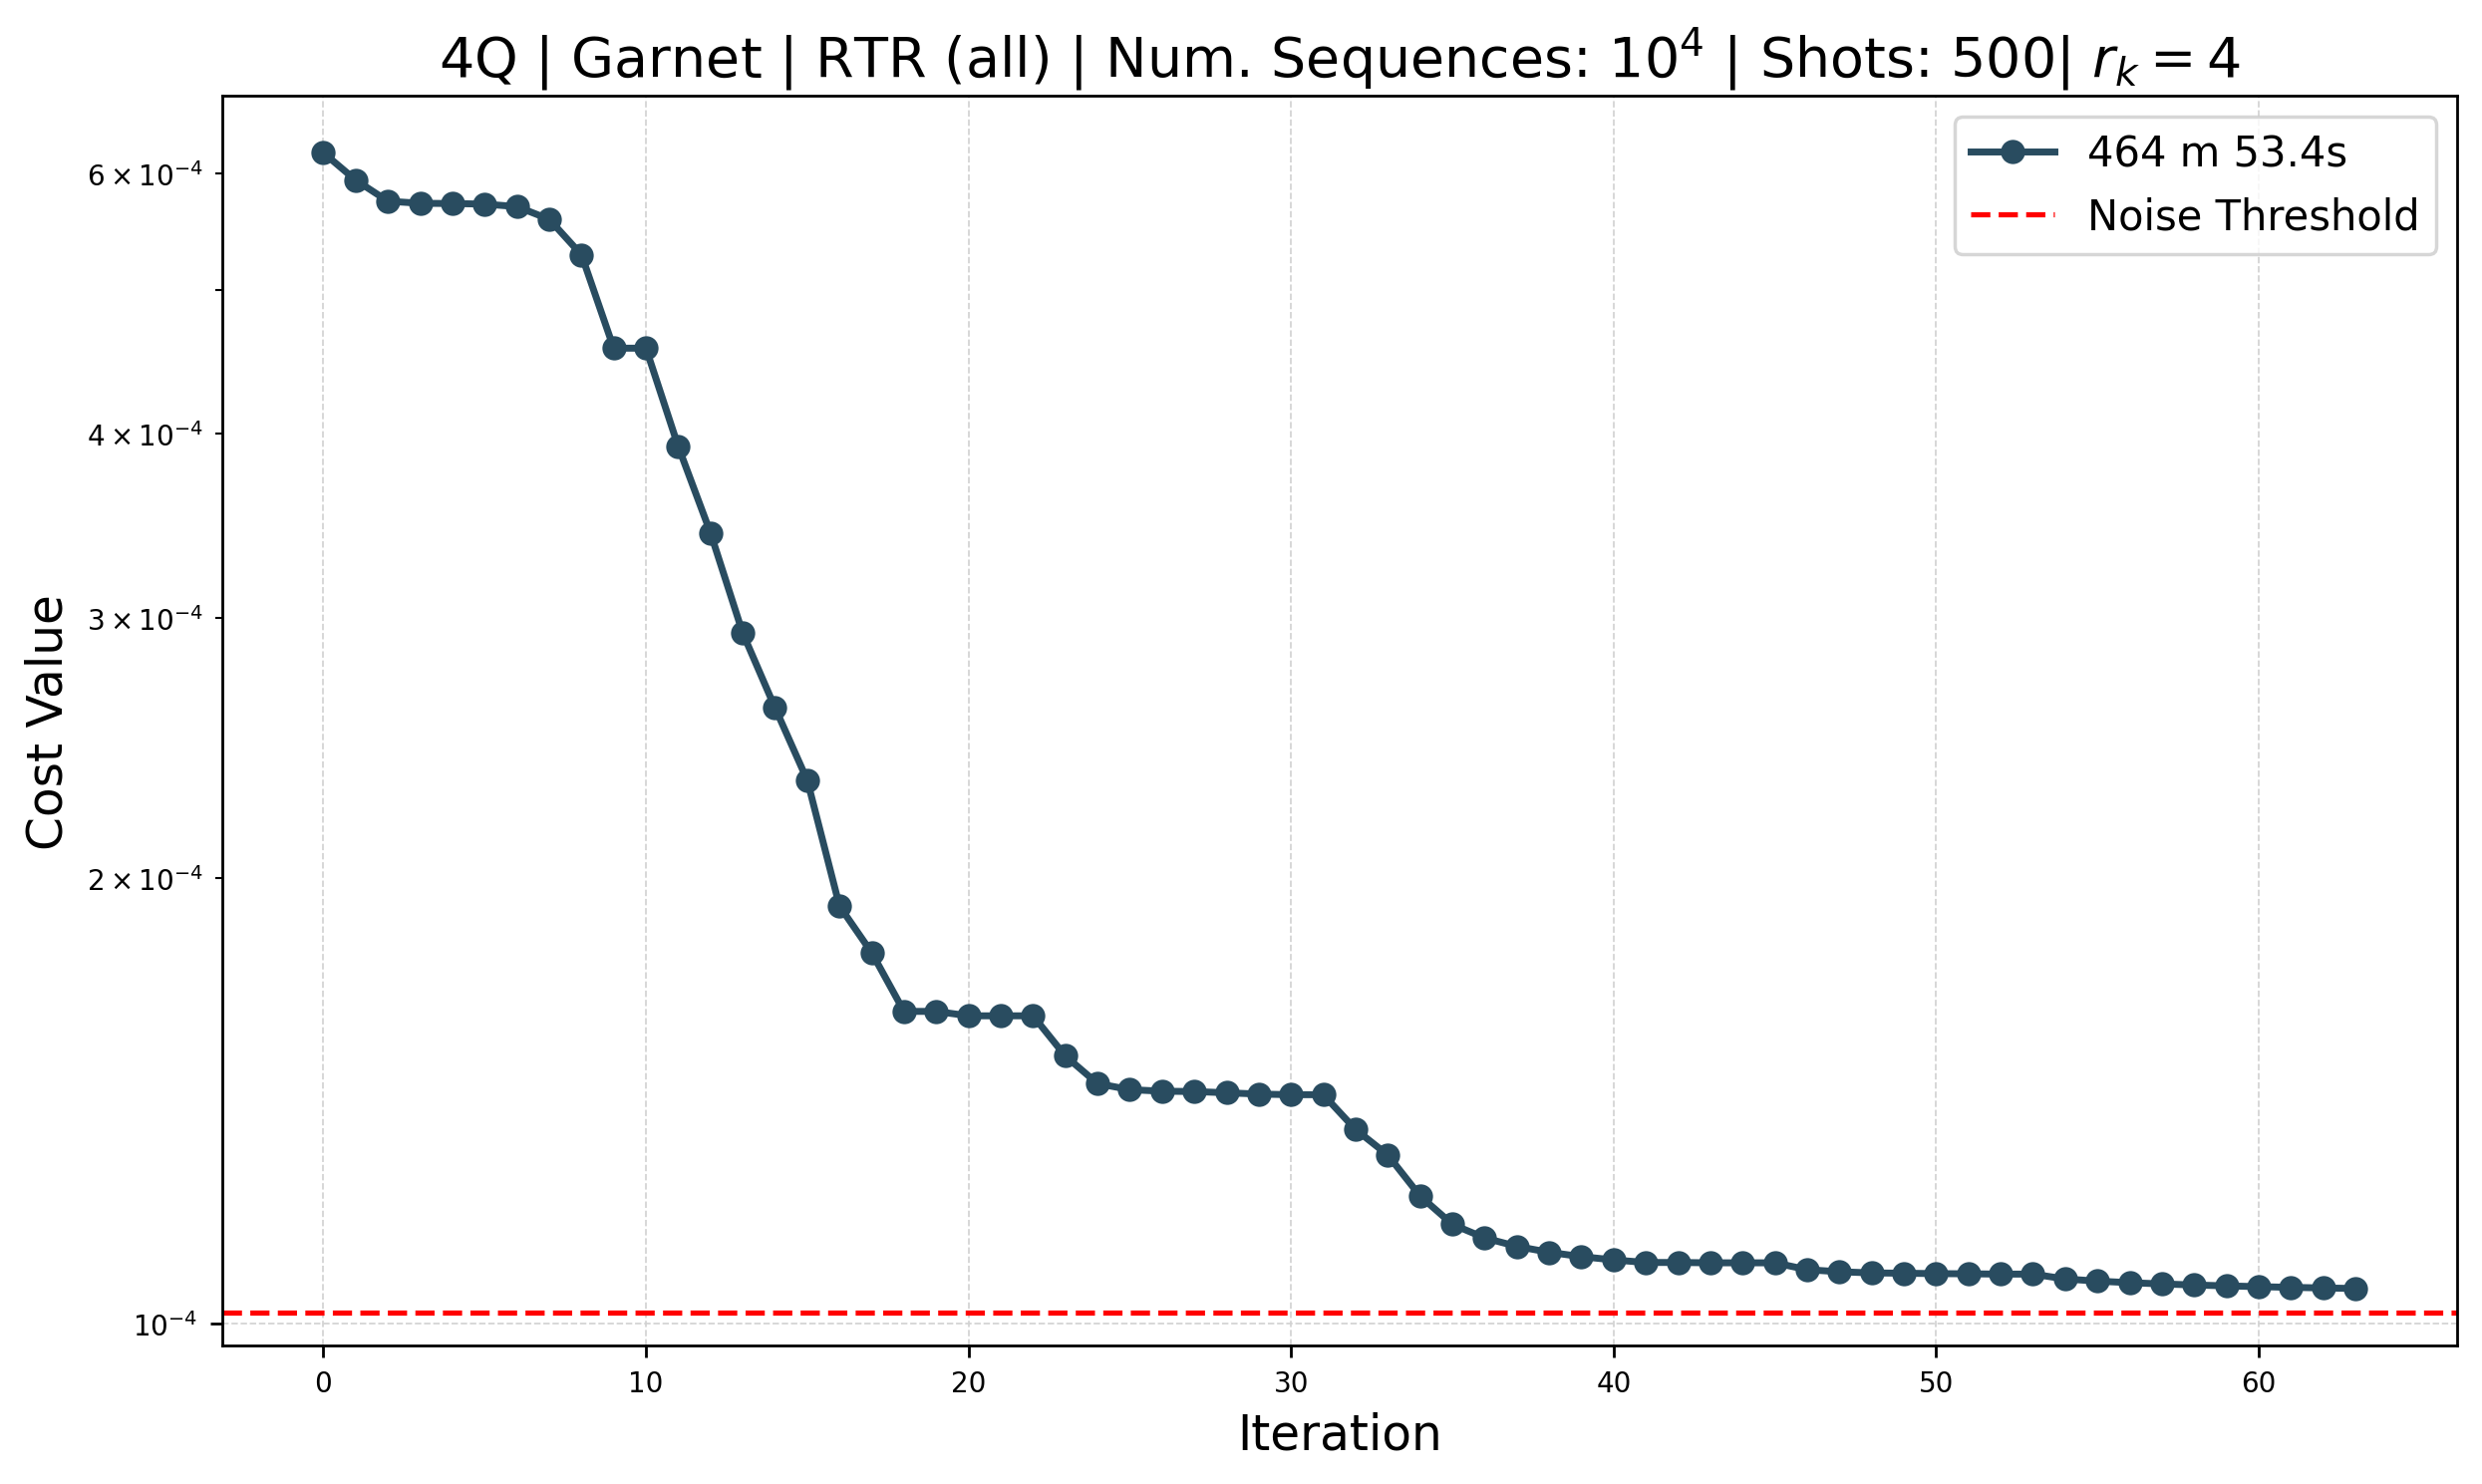

In [ ]:
plot_cost_function(
    cost_array=[cost_fn_history],
    labels=[r"464 m 53.4s"],
    comparison_yline=noise_threshold,
    comparison_label="Noise Threshold",
    title="4Q | Garnet | RTR (all) | Num. Sequences: $10^4$ | Shots: 500| $r_k = 4, r_A = $"
)

# Gauge optimization

In [85]:
gauge_weights = {'G0': 1,
 'G1': 1,
 'G2': 1,
 'G3': 1,
 'G4': 1,
 'G5': 1,
 'G6': 1,
 'G7': 1,
 'G8': 1,
 'spam': 0.1}

kraus_tensor_opt = optimized_operators["kraus"]
povm_psd_opt = optimized_operators["povm"]
state_psd_opt = optimized_operators["state"]

In [82]:
target_ops = {
    "X": kraus_superop_target,
    "E": povm_mgst,
    "rho": state_mgst
}

target_model_pygsti = arrays_to_pygsti_model(**target_ops, basis="std")

[op.shape for op in target_ops.values()]

[(9, 256, 256), (16, 256), (256,)]

In [86]:
optimized_ops_mgst = get_mgst_tensors_from_psd_representation(kraus_tensor_opt, povm_psd_opt, state_psd_opt)
[(key, op.shape) for key, op in optimized_ops_mgst.items()]

[('kraus', (9, 256, 256)), ('povm', (16, 256)), ('state', (256,))]

In [87]:
kraus_mgst_gauge_opt, povm_mgst_gauge_opt, state_mgst_gauge_opt = gauge_opt(
    X=optimized_ops_mgst["kraus"],
    E=optimized_ops_mgst["povm"],
    rho=optimized_ops_mgst["state"],
    target_mdl=target_model_pygsti,
    weights=gauge_weights)

In [89]:
# what are their shapes?
kraus_mgst_gauge_opt.shape, povm_mgst_gauge_opt.shape, state_mgst_gauge_opt.shape

((9, 256, 256), (16, 256), (256,))

### Note:
it took `10 mins 31.5 s` to optimize the Gauge for this Gate Set!

## Save gauge optimized operators

In [90]:
jnp.savez(
    "gauge_optimized_MGST_operators_4q_rank_4_all.npz",
    kraus_tensor_mgst=kraus_mgst_gauge_opt,
    povm_mgst=povm_mgst_gauge_opt,
    state_mgst=state_mgst_gauge_opt,
)

# Basic checks on the gauge optimized operators

In [91]:
rank = 4

In [93]:
kraus_tensor_gauge_opt, povm_psd_gauge_opt, state_psd_gauge_opt = get_compressed_rep_from_mgst_output(
    kraus_mgst=kraus_mgst_gauge_opt,
    povm_mgst=povm_mgst_gauge_opt,
    state_mgst=state_mgst_gauge_opt,
    kraus_rank=rank, state_rank=rank, povm_rank=rank)

gauge_opt_psd_operators = {
    "kraus_tensor": kraus_tensor_gauge_opt,
    "povm_psd": povm_psd_gauge_opt,
    "state_psd": state_psd_gauge_opt,
}

[op.shape for op in gauge_opt_psd_operators.values()]

[(9, 4, 16, 16), (16, 4, 16), (16, 4)]

In [94]:
# Checking the cost function is the same as for the optimized operators without gauge optimization
cost_value_opt = cost_function_jax_mps(*optimized_operators.values(), **cost_fn_kwargs)
cost_value_gauge_opt = cost_function_jax_mps(**gauge_opt_psd_operators, **cost_fn_kwargs)

print("Are the costs the same?", jnp.allclose(cost_value_gauge_opt, cost_value_opt))
print("cost:", cost_value_gauge_opt, cost_value_opt)

Are the costs the same? True
cost: 0.00010560322854027844 0.00010560322854027894
